# Análisis exploratorio de datos.
## Grupo 2

## Inicio.

### Importación de datos

In [1]:
import pandas as pd
import numpy as np
import warnings
import random
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox

### Importación de datos

In [2]:
df = pd.read_csv('train.csv', index_col=0)
df.head(3)

,LME_AH_Close,LME_CA_Close,LME_PB_Close,LME_ZS_Close,JPX_Gold_Mini_Futures_Open,JPX_Gold_Rolling-Spot_Futures_Open,JPX_Gold_Standard_Futures_Open,JPX_Platinum_Mini_Futures_Open,JPX_Platinum_Standard_Futures_Open,JPX_RSS3_Rubber_Futures_Open,...,FX_GBPCAD,FX_CADCHF,FX_NZDCAD,FX_NZDCHF,FX_ZAREUR,FX_NOKGBP,FX_NOKCHF,FX_ZARCHF,FX_NOKJPY,FX_ZARGBP
date_id,,,,,,,,,,,,,,,,,,,,,
0,2264.5,7205.0,2570.0,3349.0,NaN,NaN,NaN,NaN,NaN,NaN,...,1.699987,0.776874,0.888115,0.689954,0.066653,0.090582,0.119630,0.078135,13.822740,0.059163
1,2228.0,7147.0,2579.0,3327.0,NaN,NaN,NaN,NaN,NaN,NaN,...,1.695279,0.778682,0.889488,0.692628,0.067354,0.091297,0.120520,0.079066,13.888146,0.059895
2,2250.0,7188.5,2587.0,3362.0,4684.0,4691.0,4684.0,3363.0,3367.0,207.0,...,1.692724,0.780186,0.894004,0.697490,0.067394,0.091478,0.120809,0.079287,13.983675,0.060037


In [3]:
df_labels = pd.read_csv('train_labels.csv', index_col=0)
df_labels.head(3)

,target_0,target_1,target_2,target_3,target_4,target_5,target_6,target_7,target_8,target_9,...,target_414,target_415,target_416,target_417,target_418,target_419,target_420,target_421,target_422,target_423
date_id,,,,,,,,,,,,,,,,,,,,,
0,0.005948,-0.002851,-0.004675,-0.000639,NaN,NaN,-0.006729,0.006066,NaN,0.003446,...,NaN,0.021239,-0.005595,NaN,-0.004628,0.033793,NaN,0.038234,NaN,0.027310
1,0.005783,-0.024118,-0.007052,-0.018955,-0.031852,-0.019452,0.003002,-0.006876,-0.002042,0.021284,...,0.003377,0.021372,-0.001517,0.012846,0.010547,0.030527,-0.000764,0.025021,0.003548,0.020940
2,0.001048,0.023836,-0.008934,-0.022060,NaN,NaN,0.037449,0.007658,NaN,-0.026844,...,-0.006712,0.009308,0.001857,-0.012761,-0.002345,0.017529,-0.005394,0.004835,-0.009075,0.001706


In [4]:
labels = pd.read_csv('target_pairs.csv')
labels.head(3)

,target,lag,pair
0,target_0,1,US_Stock_VT_adj_close
1,target_1,1,LME_PB_Close - US_Stock_VT_adj_close
2,target_2,1,LME_CA_Close - LME_ZS_Close


## Relación entre conjuntos de datos.

### Tamaño de los conjuntos de datos.

In [5]:
print(df.shape)
print(df_labels.shape)
print(labels.shape)

(1961, 557)
(1961, 424)
(424, 3)


Los conjuntos df y df_labels tienen la misma cantidad de filas, pero no columnas.  
El conjunto df_labels tiene la misma cantidad de columnas que la cantidad de filas del conjunto labels.  
Esto no es coincidencia, en los siguientes incisos se mostrará la relación.

### Comprobando la relación de los índices de df y df_labels.

In [6]:
(df.index == df_labels.index).all()

np.True_

Esto indica que df y df_labels están relacionados mediante el mismo índice date_id.

### Comprobando la relación entre columnas de df_labes con las filas de labels.

In [7]:
(np.array(df_labels.columns) == np.array(labels['target'])).all()

np.True_

Las filas del conjunto labels dan explicación de cómo se construye el cojunto df_labels a partir del conjunto df.

## Valores faltantes, tipos de variables y estadísticas preliminares.

### Observando valores faltantes.

In [8]:
columnas_solo_nan_df = df.columns[df.isna().all()]
print(columnas_solo_nan_df)

Index([], dtype='object')


In [9]:
columnas_solo_nan_df_labels = df_labels.columns[df_labels.isna().all()]
print(columnas_solo_nan_df_labels)

Index([], dtype='object')


In [10]:
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

US_Stock_GOLD_adj_open      1713
US_Stock_GOLD_adj_close     1713
US_Stock_GOLD_adj_high      1713
US_Stock_GOLD_adj_low       1713
US_Stock_GOLD_adj_volume    1713
                            ... 
US_Stock_YINN_adj_volume      67
LME_ZS_Close                  51
LME_PB_Close                  51
LME_CA_Close                  51
LME_AH_Close                  51
Length: 519, dtype: int64

In [11]:
df_labels.isna().sum()[df_labels.isna().sum() > 0].sort_values(ascending=False)

target_404    370
target_82     359
target_302    350
target_288    350
target_286    350
             ... 
target_39      86
target_29      86
target_26      86
target_23      86
target_2       86
Length: 422, dtype: int64

Hay muchos valores faltantes y hay columnas que tienen en su gran mayoría solo valores faltantes. Al ser datos secuenciales se usará interpolación para reemplazar los datos faltantes, tomando los dos períodos de tiempo con datos como los límites de la recta que se usará para el reemplazo de los datos.

### Tipos de variables.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1961 entries, 0 to 1960
Columns: 557 entries, LME_AH_Close to FX_ZARGBP
dtypes: float64(557)
memory usage: 8.3 MB


In [13]:
df_labels.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1961 entries, 0 to 1960
Columns: 424 entries, target_0 to target_423
dtypes: float64(424)
memory usage: 6.4 MB


In [14]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  424 non-null    object
 1   lag     424 non-null    int64 
 2   pair    424 non-null    object
dtypes: int64(1), object(2)
memory usage: 10.1+ KB


En los conjuntos df y df_labels, todas las variables son del tipo flotante, a excepción del índice que es entera.  
En el conjunto labels se tienen dos tipo object, una que indica la relación con el conjunto df_label y otra que explica como formar la variable de ese mismo conjunto con las variables. Además, tiene una variable que indica el desplazamiento temporal sobre el cual se hará la diferencia.

### Separando el conjunto de entrenamiento (para ver las estadísticas)

In [15]:
muestra_filas = int(df.shape[0]*0.8)
df2 = df.copy()
df = df.iloc[:muestra_filas, :]
df_labels = df_labels.iloc[:muestra_filas, :]

### Viendo las estadísticas de algunas columnas.

In [16]:
random.seed(0)
muestra_columnas_df = random.sample(list(df.columns), 20)
df[muestra_columnas_df].describe()

,US_Stock_SLV_adj_close,US_Stock_BCS_adj_volume,JPX_Platinum_Mini_Futures_open_interest,US_Stock_FXI_adj_low,FX_EURAUD,US_Stock_TRGP_adj_volume,US_Stock_VWO_adj_close,US_Stock_VCIT_adj_low,US_Stock_SLB_adj_volume,US_Stock_HES_adj_close,US_Stock_VTV_adj_high,US_Stock_XLE_adj_volume,US_Stock_AGG_adj_high,US_Stock_OIH_adj_low,US_Stock_ALB_adj_high,US_Stock_NUGT_adj_open,US_Stock_EMB_adj_low,FX_AUDCHF,US_Stock_BSV_adj_high,US_Stock_VT_adj_low
count,1516.000000,1.516000e+03,1473.000000,1516.000000,1568.000000,1.516000e+03,1516.000000,1516.000000,1.516000e+03,1516.000000,1516.000000,1.516000e+03,1516.000000,1516.000000,1516.000000,1516.000000,1516.000000,1568.000000,1516.000000,1516.000000
mean,19.001471,5.677869e+06,1055.866259,35.228368,1.595332,2.236784e+06,38.132349,73.701921,1.184877e+07,79.491626,111.940494,2.386553e+07,95.447646,256.168287,144.446668,73.104357,82.556497,0.668564,71.235779,78.386029
std,3.757653,5.558657e+06,482.219564,6.232722,0.057849,2.150642e+06,4.520808,5.629788,5.655310e+06,36.183864,19.823558,1.207785e+07,5.981150,103.735158,70.914038,40.483059,6.716233,0.047253,2.622470,13.297520
min,11.210000,8.270000e+05,75.000000,19.961400,1.431856,3.726730e+05,26.122000,64.700000,3.077628e+06,26.951300,69.606000,5.037439e+06,85.895800,61.752800,51.442500,20.778300,66.751100,0.561661,66.485500,48.501800
25%,15.560000,2.796090e+06,730.000000,29.525500,1.563652,1.396985e+06,34.993950,69.666075,8.088091e+06,52.393725,92.731425,1.487599e+07,90.032350,190.328900,81.663550,41.213875,76.875825,0.641887,69.484475,65.088675
50%,19.505000,4.224634e+06,1027.000000,36.527900,1.598508,1.793266e+06,37.497600,72.763800,1.061576e+07,62.812050,107.831700,2.131479e+07,94.011850,244.659800,128.488700,63.253200,81.154600,0.671439,71.158300,79.026650
75%,22.142500,7.091731e+06,1359.000000,39.657875,1.628766,2.418156e+06,39.814700,79.590525,1.396423e+07,108.934650,131.989750,2.949568e+07,102.101650,308.711225,211.004800,95.917800,89.081950,0.700076,74.025350,90.679525
max,27.000000,1.476120e+08,5064.000000,50.752700,1.886723,4.903322e+07,49.423800,83.017600,8.614796e+07,162.812800,146.340900,9.935671e+07,105.132700,523.280600,324.250600,209.190100,94.336400,0.770534,74.878200,101.273300


In [17]:
random.seed(0)
muestra_columnas_labels = random.sample(list(df_labels.columns), 20)
df_labels[muestra_columnas_labels].describe()

,target_197,target_388,target_215,target_20,target_132,target_261,target_248,target_207,target_401,target_155,target_244,target_183,target_298,target_111,target_258,target_71,target_144,target_386,target_48,target_316
count,1391.000000,1413.000000,1314.000000,1497.000000,1413.000000,1290.000000,1413.000000,1292.000000,1413.000000,1484.000000,1413.000000,1292.000000,1413.000000,1313.000000,1413.000000,1401.000000,1413.000000,1484.000000,1426.000000,1413.000000
mean,0.000847,-0.000885,-0.001370,-0.000016,0.000271,-0.001284,-0.000013,0.000121,-0.000928,-0.000057,0.001374,-0.000363,-0.000333,0.000926,-0.000078,-0.000496,-0.002170,-0.000692,0.000004,0.002076
std,0.023605,0.032306,0.025112,0.015786,0.033492,0.050534,0.039364,0.019202,0.032474,0.018503,0.063966,0.033546,0.028892,0.023543,0.027080,0.009993,0.044036,0.026648,0.023852,0.034684
min,-0.167510,-0.138604,-0.100159,-0.065950,-0.262895,-0.217348,-0.187322,-0.071815,-0.138864,-0.082675,-0.652450,-0.156771,-0.121972,-0.099319,-0.147404,-0.080929,-0.200884,-0.110876,-0.158647,-0.157835
25%,-0.013165,-0.021344,-0.018330,-0.009721,-0.020327,-0.030049,-0.022024,-0.010812,-0.021221,-0.010618,-0.031741,-0.019596,-0.019388,-0.013963,-0.016600,-0.006132,-0.027897,-0.017775,-0.013478,-0.017993
50%,-0.000314,-0.001064,-0.001597,0.000290,-0.000322,-0.001273,-0.000894,-0.000689,-0.001149,0.000175,0.001889,0.000564,0.000467,0.000054,0.000054,-0.000676,-0.001776,-0.000424,-0.000639,0.002010
75%,0.015055,0.018266,0.015279,0.009720,0.021182,0.029477,0.022744,0.009768,0.018129,0.010735,0.035128,0.018604,0.018066,0.015534,0.017230,0.004936,0.023518,0.016396,0.012087,0.023115
max,0.144684,0.208004,0.096413,0.073294,0.174982,0.230180,0.193015,0.140181,0.201521,0.112808,0.286121,0.155876,0.151603,0.098335,0.100895,0.074676,0.482120,0.119053,0.231038,0.197821


In [18]:
labels['lag'].value_counts()

lag
1    106
2    106
3    106
4    106
Name: count, dtype: int64

Muchas de las columnas del conjunto df tienen escalas enormes, mientras que las columnas del conjunto df_labels tienen escalas mucho más controladas (en la muestra entre -0.70 y 0.50). Esto debido a que, como se menciona en la página del concurso de Kaggle, los datos fueron operados con escalas logarítmicas para evitar problemas de escala al momento de entrenar modelos.  
La columna lag del conjunto labels muestra que se tienen desplazamientos entre 1 y 4 unidades temporales.

## Cálculo y comportamiento de variables.

### Cruzando variables para explicar etiquetas.

In [19]:
labels[labels['target'] == 'target_1']

,target,lag,pair
1,target_1,1,LME_PB_Close - US_Stock_VT_adj_close


In [20]:
df_labels['target_1']

date_id
0      -0.002851
1      -0.024118
2       0.023836
3      -0.024618
4       0.005234
          ...   
1563         NaN
1564         NaN
1565   -0.011280
1566   -0.002467
1567    0.004849
Name: target_1, Length: 1568, dtype: float64

In [21]:
ret_1 = (np.log(df['LME_PB_Close'].shift(-1)) - np.log(df['LME_PB_Close']))
ret_2 = (np.log(df['US_Stock_VT_adj_close'].shift(-1)) - np.log(df['US_Stock_VT_adj_close']))
ret_1-ret_2

date_id
0      -0.003289
1      -0.002851
2      -0.024118
3       0.023836
4      -0.024618
          ...   
1563   -0.003713
1564         NaN
1565         NaN
1566   -0.011280
1567         NaN
Length: 1568, dtype: float64

In [22]:
labels[labels['target'] == 'target_0']

,target,lag,pair
0,target_0,1,US_Stock_VT_adj_close


In [23]:
df_labels['target_0']

date_id
0       0.005948
1       0.005783
2       0.001048
3       0.001700
4      -0.003272
          ...   
1563         NaN
1564         NaN
1565   -0.007914
1566    0.008505
1567    0.009020
Name: target_0, Length: 1568, dtype: float64

In [24]:
np.log(df['US_Stock_VT_adj_close'].shift(-1))- np.log(df['US_Stock_VT_adj_close'])

date_id
0       0.006785
1       0.005948
2       0.005783
3       0.001048
4       0.001700
          ...   
1563    0.001563
1564         NaN
1565         NaN
1566   -0.007914
1567         NaN
Name: US_Stock_VT_adj_close, Length: 1568, dtype: float64

Podemos observar que a partir del conjunto df_labels puede ser formado por el conjunto labels, aunque el conjunto df_labels contiene más información, ya que las últimas dos filas no pueden ser obtenidas con la fórmula, mientras que la primera fila de la fórmula no aparece en el conjunto df_labels.

### Graficando el comportamiento de las variables (aplicando escala log).

<Axes: xlabel='date_id'>

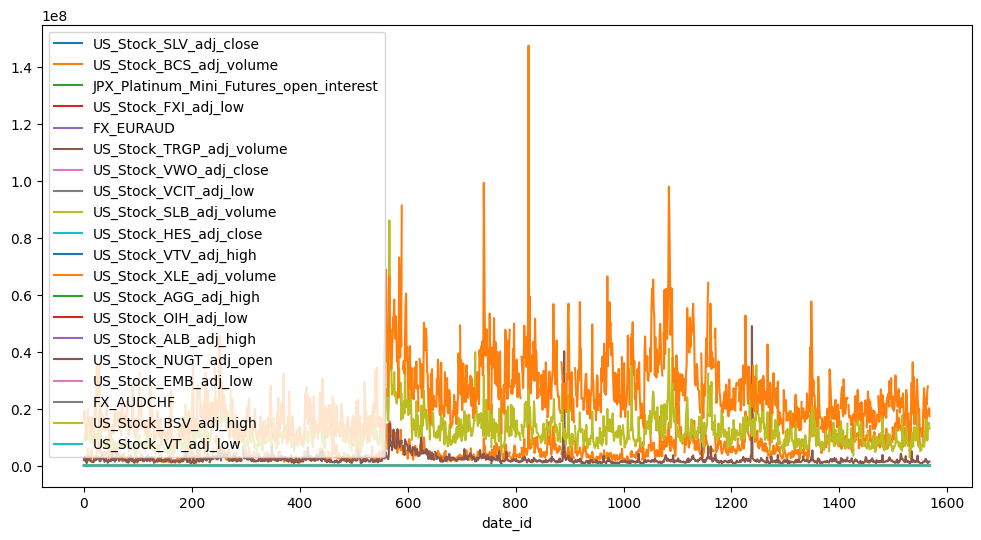

In [25]:
df.loc[:, muestra_columnas_df].plot(figsize=(12, 6))

<Axes: xlabel='date_id'>

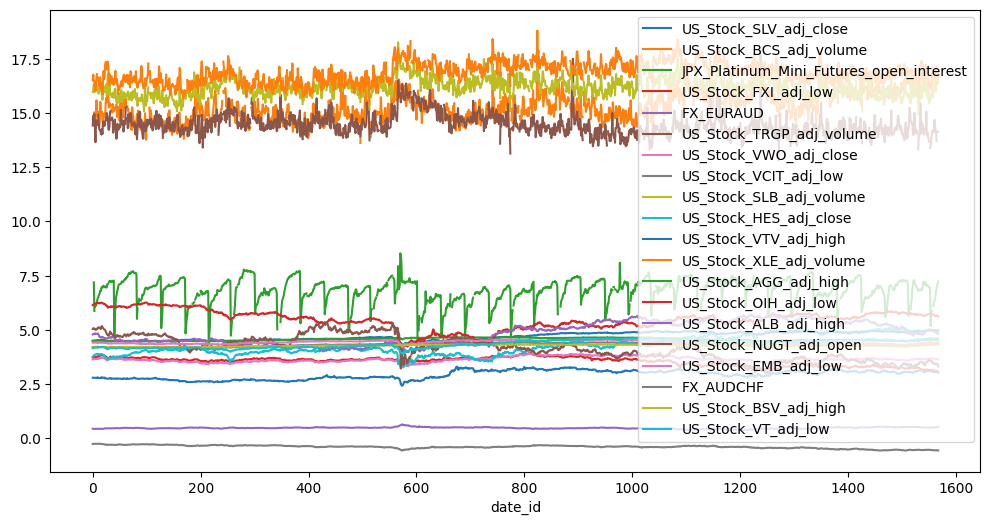

In [26]:
df_log = np.log(df)
df_log.loc[:, muestra_columnas_df].plot(figsize=(12, 6))

<Axes: xlabel='date_id'>

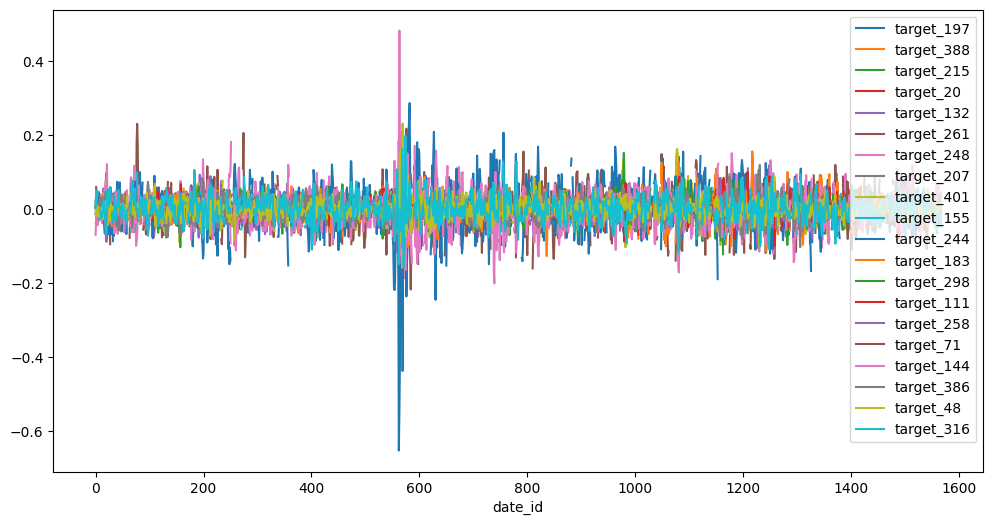

In [27]:
df_labels.loc[:, muestra_columnas_labels].plot(figsize=(12, 6))

En el primer gráfico podemos observar que escalar con log, permitió tener escalas mucho más manejables.  
En el segundo gráfico podemos observar que las targets de muestra están centradas alrededor de 0 y tienen escalas pequeñas, lo cual puede mejorar la capacidad predictiva y de generalización del modelo.

## Obteniendo las variables si son usadas en labels.

In [28]:
variables_usadas = set()
for x in labels['pair']:
    variables = x.split(' - ')
    for y in variables:
        variables_usadas.add(y)

variables_usadas = list(variables_usadas)
len(variables_usadas)

106

Solo 106 variables son usadas, por lo cual son las únicas que se conservarán.

## Pruebas estadísticas.

### Valores faltantes.

In [29]:
df2[variables_usadas].isna().sum()[df2.isna().sum() > 0].sort_values(ascending=False)

JPX_Gold_Standard_Futures_Close        116
JPX_Platinum_Standard_Futures_Close    116
US_Stock_X_adj_close                    92
US_Stock_HES_adj_close                  72
US_Stock_CVX_adj_close                  67
                                      ... 
US_Stock_IEMG_adj_close                 67
LME_AH_Close                            51
LME_PB_Close                            51
LME_CA_Close                            51
LME_ZS_Close                            51
Length: 73, dtype: int64

### Muestra df_log y diferenciados.

In [30]:
muestra_log_original = df_log[variables_usadas].copy()

# Se reemplaza los faltantes por la media (No será el proceso usado, solo se usará para poder medir estadísticas)
muestra_log_original = muestra_log_original.fillna(muestra_log_original.mean())

muestra_log_diff_1 = muestra_log_original.diff(1)[1:]
muestra_log_diff_2 = muestra_log_original.diff(2)[2:]
muestra_log_diff_3 = muestra_log_original.diff(3)[3:]
muestra_log_diff_4 = muestra_log_original.diff(4)[4:]

muestras_dfs = [muestra_log_diff_1, muestra_log_diff_2, muestra_log_diff_3, muestra_log_diff_4]

### Media, Desviación estándar, mediana, curtosis, sesgo e IQR en muestra df_log.

In [31]:
resumenes = []

for data in muestras_dfs:
    resumen = pd.DataFrame(index=muestra_log_original.columns)

    # Media
    resumen["Media"] = data.mean()
    # Desviación estándar
    resumen["Desv_std"] = data.std()
    # Mediana
    resumen["Mediana"] = data.median()
    # Cuartiles
    resumen["Q1"] = data.quantile(0.25)
    resumen["Q3"] = data.quantile(0.75)
    # Rango intercuartílico
    resumen["IQR"] = resumen["Q3"] - resumen["Q1"]
    # Asimetría
    resumen["Sesgo"] = data.skew()
    # Curtosis
    resumen["Curtosis"] = data.kurt()
    resumenes.append(resumen.round(2).copy())

In [32]:
resumenes[2].head(7)

,Media,Desv_std,Mediana,Q1,Q3,IQR,Sesgo,Curtosis
US_Stock_CVX_adj_close,0.0,0.08,0.0,-0.02,0.02,0.04,-0.24,16.61
US_Stock_CCJ_adj_close,0.0,0.14,0.0,-0.03,0.03,0.06,-0.32,18.92
US_Stock_HL_adj_close,0.0,0.13,-0.0,-0.04,0.04,0.08,-0.00,19.00
US_Stock_DVN_adj_close,0.0,0.16,0.0,-0.03,0.04,0.07,-0.36,23.28
US_Stock_TECK_adj_close,0.0,0.12,0.0,-0.03,0.04,0.07,-0.17,22.50
FX_AUDCAD,-0.0,0.01,0.0,-0.00,0.00,0.01,-0.08,2.01
US_Stock_X_adj_close,-0.0,0.14,0.0,-0.04,0.04,0.08,-0.16,23.93


In [33]:
df['JPX_Gold_Mini_Futures_Open']

date_id
0          NaN
1          NaN
2       4684.0
3       4728.0
4          NaN
         ...  
1563    9450.0
1564    9508.0
1565    9509.0
1566    9597.5
1567    9627.0
Name: JPX_Gold_Mini_Futures_Open, Length: 1568, dtype: float64

Hay algunas columnas que tienen muchos nan, pero son usadas, se tratarán en el notebook de limpieza.

In [34]:
def contar_criterios(df):
    
    # Criterios booleanos para cada fila
    criterios = pd.DataFrame(index=df.index)

    # 1. Media cercana a cero respecto a su propia desviación estándar
    criterios["media_cercana_0"] = (df["Media"].abs() <= 0.1 * df["Desv_std"])

    # 2. Mediana cercana a cero respecto a su desviación estándar
    criterios["mediana_cercana_0"] = (df["Mediana"].abs() <= 0.1 * df["Desv_std"])

    # 3. Media y mediana relativamente próximas
    criterios["media_mediana_similares"] = ((df["Media"] - df["Mediana"]).abs() <= 0.1 * df["Desv_std"])

    # 4. Sesgo pequeño
    criterios["sesgo_bajo"] = (df["Sesgo"].abs() <= 0.5)

    # 5. Curtosis positiva
    criterios["curtosis_positiva"] = (df["Curtosis"] > 0)

    # 6. Desviación estándar positiva
    criterios["std_positiva"] = (df["Desv_std"] > 0)

    # 7. IQR positivo
    criterios["iqr_positivo"] = (df["IQR"] > 0)

    # Número de filas válidas para cada criterio
    cantidad = criterios.sum()

    # Número de filas que realmente tienen datos
    n_validas = df["Media"].notna().sum()

    porcentaje = cantidad / n_validas * 100
    return pd.DataFrame({"cantidad": cantidad, "porcentaje": porcentaje})

criterios = []

for x in resumenes:
    criterios.append(contar_criterios(x))

In [35]:
criterios[0]

,cantidad,porcentaje
media_cercana_0,106,100.000000
mediana_cercana_0,106,100.000000
media_mediana_similares,106,100.000000
sesgo_bajo,106,100.000000
curtosis_positiva,106,100.000000
std_positiva,99,93.396226
iqr_positivo,100,94.339623


In [36]:
criterios[1]

,cantidad,porcentaje
media_cercana_0,106,100.000000
mediana_cercana_0,106,100.000000
media_mediana_similares,106,100.000000
sesgo_bajo,103,97.169811
curtosis_positiva,106,100.000000
std_positiva,105,99.056604
iqr_positivo,104,98.113208


In [37]:
criterios[2]

,cantidad,porcentaje
media_cercana_0,106,100.00000
mediana_cercana_0,106,100.00000
media_mediana_similares,106,100.00000
sesgo_bajo,98,92.45283
curtosis_positiva,106,100.00000
std_positiva,106,100.00000
iqr_positivo,106,100.00000


In [38]:
criterios[3]

,cantidad,porcentaje
media_cercana_0,106,100.000000
mediana_cercana_0,106,100.000000
media_mediana_similares,106,100.000000
sesgo_bajo,96,90.566038
curtosis_positiva,106,100.000000
std_positiva,106,100.000000
iqr_positivo,106,100.000000


La media, mediana y curtosis se comportan muy bien. En algunas columnas se tiene un sesgo alto, por lo que una transformación Box-Cox es algo que se evaluará en el preprocesamiento del pipeline de los modelos. Las desviaciones estándar y el IQR también tienen un buen comportamiento, pero existen algunas series en las que se hacen 0.

### Silenciando advertencias.

In [39]:
warnings.filterwarnings("ignore", category=InterpolationWarning)

### Estacionariedad de medias.

$\alpha = 0.05$

$\textbf{ADF}$  
$H_0:$ La serie no es estacionaria en media.  
$H_a:$ La serie es estacionaria en media.

$\textbf{KPSS}$   
$H_0:$ La serie es estacionaria en media.  
$H_a:$ La serie no es estacionaria en media.

In [40]:
def estacionariedad_media(datos, alpha):
    adf = adfuller(datos, regression="c")[1]
    kpss_test = kpss(datos, regression="c", nlags="auto")[1]
    flag = 0

    if adf >= alpha:
        flag = 1
   
    if kpss_test < alpha:
        flag = 1

    return flag

# Alpha
alpha = 0.05

In [41]:
no_estacionarias_media = []
columna_lag_media = []

lag_usado = 0
for x in muestras_dfs:
    contador = 0
    lag_usado += 1

    for y in x.columns:
        if estacionariedad_media(x[y], alpha) == 1:
            contador += 1
            columna_lag_media.append((y, lag_usado))

    no_estacionarias_media.append(contador)

print(no_estacionarias_media)
print(columna_lag_media)

[1, 1, 2, 2]
[('FX_CHFJPY', 1), ('FX_CHFJPY', 2), ('FX_CHFJPY', 3), ('FX_EURJPY', 3), ('FX_CHFJPY', 4), ('FX_EURJPY', 4)]


No todas las columnas de la muestra presentaron estacionariedad, pero estas serán evaluadas para saber si son útiles en el modelo.

### Varianza estacionaria.

In [42]:
def estacionariedad_varianza(datos, alpha):
    arch = het_arch(datos)[1]
    flag = 0

    if arch < alpha:
        flag = 1

    return flag

In [43]:
no_estacionarias_varianza = []
columna_lag_varianza = []

lag_usado = 0
for x in muestras_dfs:
    contador = 0
    lag_usado += 1

    for y in x.columns:
        if estacionariedad_varianza(x[y], alpha) == 1:
            contador += 1
            columna_lag_varianza.append((y, lag_usado))

    no_estacionarias_varianza.append(contador)

print(no_estacionarias_varianza)
print(columna_lag_varianza[:10])

[106, 106, 106, 106]
[('US_Stock_CVX_adj_close', 1), ('US_Stock_CCJ_adj_close', 1), ('US_Stock_HL_adj_close', 1), ('US_Stock_DVN_adj_close', 1), ('US_Stock_TECK_adj_close', 1), ('FX_AUDCAD', 1), ('US_Stock_X_adj_close', 1), ('LME_AH_Close', 1), ('US_Stock_IAU_adj_close', 1), ('US_Stock_VALE_adj_close', 1)]


Todos fallan en la estacionariedad en varianza, se evaluará el uso de transformaciones Box-Cox para cumplir con los supuestos de SARIMA y SARFIMA. Los modelos GARCH si usan series que necesitan heterocedasticidad, por lo cual no hay necesidad de aplicarles ningún preprocesamiento.

### Volatilidad a través del tiempo.

In [44]:
volatilidad_tiempo = {"lag_5": [], "lag_10": [], "lag_20": []}
columna_lag_volatilidad = set()

for lag_usado, x in enumerate(muestras_dfs, start=1):
    conteos = {5: 0, 10: 0, 20: 0}

    for columna in x.columns:
        serie = x[columna].dropna()

        if len(serie) <= 20:
            continue

        ljung = acorr_ljungbox(serie**2, lags=[5, 10, 20], return_df=True)

        for lag in [5, 10, 20]:
            if ljung.loc[lag, "lb_pvalue"] >= alpha:
                conteos[lag] += 1
                columna_lag_volatilidad.add((lag_usado, columna, lag))

    for lag in [5, 10, 20]:
        volatilidad_tiempo[f"lag_{lag}"].append(conteos[lag])

print(volatilidad_tiempo)
print(columna_lag_volatilidad)

{'lag_5': [0, 0, 0, 0], 'lag_10': [0, 0, 0, 0], 'lag_20': [0, 0, 0, 0]}
set()


Todas las columnas cumplen con el criterio de volatilidad para los lag 5, 10 y 20.

### Autocorrelaciones y estacionalidad.

In [45]:
nlags = 20
periodos_estacionales = [5, 20]

criterios_ts = {
    "sin_acf": [],
    "sin_pacf": [],
    "sin_estacionalidad": []
}

columnas_no_cumplen = set()

for lag_usado, x in enumerate(muestras_dfs, start=1):
    conteos = {"acf": 0, "pacf": 0, "estacionalidad": 0}

    for columna in x.columns:
        serie = x[columna].dropna()

        if len(serie) <= nlags:
            continue

        acf_val, acf_ci = acf(serie, nlags=nlags, alpha=alpha, fft=True)
        pacf_val, pacf_ci = pacf(serie, nlags=nlags, alpha=alpha)

        acf_sig = (acf_ci[1:, 0] > 0) | (acf_ci[1:, 1] < 0)
        pacf_sig = (pacf_ci[1:, 0] > 0) | (pacf_ci[1:, 1] < 0)

        # Al menos un lag significativo
        if not acf_sig.any():
            conteos["acf"] += 1
            columnas_no_cumplen.add((lag_usado, columna, "ACF"))

        if not pacf_sig.any():
            conteos["pacf"] += 1
            columnas_no_cumplen.add((lag_usado, columna, "PACF"))

        # Algún periodo estacional con ACF significativa
        estacional = any(acf_sig[p - 1] for p in periodos_estacionales if p <= nlags)

        if not estacional:
            conteos["estacionalidad"] += 1
            columnas_no_cumplen.add((lag_usado, columna, "Estacionalidad"))

    criterios_ts["sin_acf"].append(conteos["acf"])
    criterios_ts["sin_pacf"].append(conteos["pacf"])
    criterios_ts["sin_estacionalidad"].append(conteos["estacionalidad"])

print(criterios_ts)
print(columnas_no_cumplen)

{'sin_acf': [1, 0, 0, 0], 'sin_pacf': [1, 0, 0, 0], 'sin_estacionalidad': [86, 96, 101, 88]}
{(3, 'US_Stock_MPC_adj_close', 'Estacionalidad'), (1, 'FX_CADJPY', 'ACF'), (2, 'FX_GBPJPY', 'Estacionalidad'), (4, 'US_Stock_SPYV_adj_close', 'Estacionalidad'), (4, 'US_Stock_DVN_adj_close', 'Estacionalidad'), (3, 'US_Stock_VXUS_adj_close', 'Estacionalidad'), (3, 'US_Stock_XLB_adj_close', 'Estacionalidad'), (4, 'FX_GBPNZD', 'Estacionalidad'), (3, 'US_Stock_ENB_adj_close', 'Estacionalidad'), (3, 'US_Stock_TECK_adj_close', 'Estacionalidad'), (3, 'FX_CADCHF', 'Estacionalidad'), (3, 'US_Stock_VALE_adj_close', 'Estacionalidad'), (2, 'US_Stock_HAL_adj_close', 'Estacionalidad'), (4, 'FX_EURCHF', 'Estacionalidad'), (4, 'US_Stock_OKE_adj_close', 'Estacionalidad'), (2, 'FX_CHFJPY', 'Estacionalidad'), (1, 'US_Stock_BNDX_adj_close', 'Estacionalidad'), (4, 'US_Stock_EWT_adj_close', 'Estacionalidad'), (3, 'US_Stock_X_adj_close', 'Estacionalidad'), (2, 'US_Stock_XLB_adj_close', 'Estacionalidad'), (2, 'FX_EURU